In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.stats import ks_2samp
import itertools
from scipy.stats import gaussian_kde
from statsmodels.stats.multitest import multipletests

import os
while not os.path.isdir('.git'):
    os.chdir('..')

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

# Random Poisson Input Figure

- A: synaptic weight dynamics
- B: final synaptic weights

In [2]:
def expand_time(original, max_time = 10_000):
    original["Time"] = (original["Time"] / 0.025).round() * 0.025
    original = original.sort_values("Time")

    new_time = np.arange(0, max_time + 0.025, 0.025)

    expanded = pd.DataFrame({ "Time": new_time })
    expanded = pd.merge_asof(expanded, original, on = "Time", direction = "backward")

    return expanded

In [3]:
def read_frequency_weights(frequency):
    global project, idxs
    
    conditions = {
        "No TI": [ f"output/{project}/{idx}/random_poisson/{frequency}/noTI_0.1/synapse_weights.csv" for idx in idxs ],
        "1k Carrier": [ f"output/{project}/{idx}/random_poisson/{frequency}/1000_130_0.9_0.1/synapse_weights.csv" for idx in idxs ],
        "9k Carrier": [ f"output/{project}/{idx}/random_poisson/{frequency}/9000_130_0.2_0.1/synapse_weights.csv" for idx in idxs ]
    }

    weights = {}
    time = []
    for (condition, filename) in conditions.items():
        weights[condition] = []
        for file in conditions[condition]:
            synapse_weights = pd.read_csv(file, index_col = 0)
            synapse_weights = expand_time(synapse_weights)
            time = synapse_weights.Time.to_list()

            synapse_weights = np.array([ synapse_weights[f"Synapse{i}"] for i in range(0, 10) ])
            weights[condition].append(synapse_weights)

        weights[condition] = np.array(weights[condition])
        weights[condition] = weights[condition].reshape((weights[condition].shape[0] * weights[condition].shape[1], weights[condition].shape[2]))

    return np.array(time) / 1000, weights

In [4]:
# Plot parameters
mpl.rcParams["axes.labelsize"] = 9
mpl.rcParams["xtick.labelsize"] = 9
mpl.rcParams["ytick.labelsize"] = 9
mpl.rcParams["legend.fontsize"] = 9
mpl.rcParams["axes.titlesize"] = 9

colors = {
    "No TI": "#0D0887",
    "0 Hz TI": "#B12A90",

    "1k Carrier": "#E16462",
    "9k Carrier": "#FCA636"
}

# Setup parameters
project = "temporal-interference-1"
idxs = np.arange(0, 20)
frequencies = [10]

# Read the data for all frequencies of interest
times = {}
weights = {}
for frequency in frequencies:
    print(f"Reading files for frequency {frequency} Hz")
    times[frequency], weights[frequency] = read_frequency_weights(frequency)

Reading files for frequency 10 Hz


In [5]:
def A_plot_weight_dynamics(ax, rate, weights, time, remove_left_labels):
    global colors
    
    for condition in weights.keys():
        average = np.array(weights[condition]).mean(axis = 0)
        error = weights[condition].std(axis = 0) / np.sqrt(weights[condition].shape[0])
    
        ax.plot(
            time,
            average,
            linewidth = 1,
            color = colors[condition],
            alpha = 1,
            label = condition
        )
    
        ax.fill_between(
            time, average - error, average + error,
            alpha = 0.25,
            color = colors[condition],
            edgecolor = None
        )

    ax.set_title(f"{rate} Hz", y = 1.2, fontsize = 10)

    if remove_left_labels:
        ax.tick_params(left = False, labelleft = False)

    if not remove_left_labels:
        ax.set_ylabel("Synaptic weight")
    
    ax.set_xlabel("Time, s")
    ax.set_ylim(-0.05, 0.6)
    ax.set_xticks(np.arange(0, 10 + 2, 2))
    ax.set_yticks(np.arange(0, 0.6, 0.1))
    
    sns.despine(ax = ax, top = True, right = True)
    
    ax.grid(True, alpha = 0.25)

In [6]:
def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

In [9]:
def B_plot_final_weights(ax, weights, remove_left_labels):
    ks_result = []

    # Perform statistical testing between all conditions
    for (cond1, cond2) in itertools.combinations(weights.keys(), 2):
        res = ks_2samp(weights[cond1][:, -1], weights[cond2][:, -1])
    
        ks_result.append(pd.DataFrame({
            "Condition1": [cond1],
            "Condition2": [cond2],
            "Pvalue": [res.pvalue],
            "Statistic": [res.statistic * res.statistic_sign],
            "StatisticLocation": [res.statistic_location],
            "Star": [p_to_star(res.pvalue)]
        }))
    
    # Concatenate all test results
    ks_result = pd.concat(ks_result, ignore_index = True)
    
    positions = {
        "1k Carrier": [0.35, 1.5],
        "9k Carrier": [0.4, 2]
    }

    for condition in weights.keys():
        final_weights = weights[condition][:, -1]

        sns.kdeplot(
            final_weights,
            bw_adjust = 1,
            ax = ax,
            clip = (0, 1),
            label = condition,
            fill = True,
            alpha = 0.025,
            linewidth = 0.75,
            color = colors[condition]
        )
    
        if condition == "No TI": continue
    
        test_result = ks_result[(ks_result.Condition1 == "No TI") & (ks_result.Condition2 == condition)]
        star = test_result.Star.to_list()[0]
        location = test_result.StatisticLocation.to_list()[0]
    
        kde = gaussian_kde(final_weights)
        where_y = kde(location)[0]
        where_x = location
        
        pos = positions[condition]
    
        ax.text(
            pos[0], pos[1],
            star,
            fontsize = 10,
            color = colors[condition],
            horizontalalignment = "left",
            verticalalignment = "center"
        )
        
        ax.plot(
            np.array([where_x, pos[0]]), # x
            np.array([where_y, pos[1]]), # y
            linewidth = 1,
            color = colors[condition],
            alpha = 0.75
        )
    
    ax.grid(True, alpha = 0.25)
    ax.set_xticks(np.arange(0, 1 + 0.25, 0.25))
    ax.set_ylim(0, 3)
    ax.set_yticks(np.arange(0, 3, 1))
    ax.set_xlabel("Synaptic weight")
    sns.despine(ax = ax, top = True, right = True)

    if remove_left_labels:
        ax.tick_params(left = False, labelleft = False)
        ax.set_ylabel("")

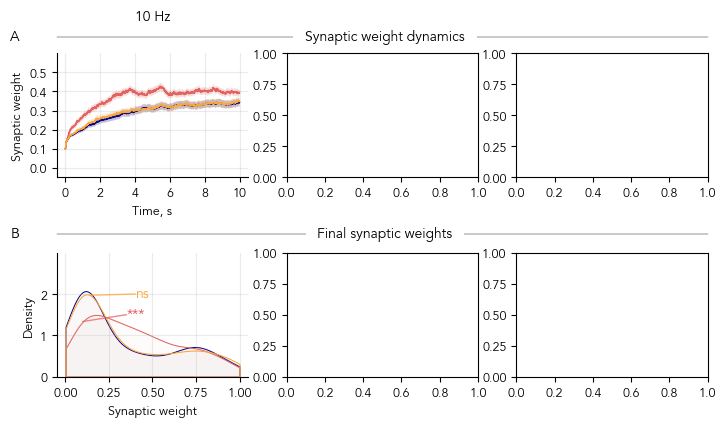

In [10]:
fig = plt.figure(figsize = (8.4, 4.2))

outer_gs = gridspec.GridSpec(3, 1, height_ratios = [1, 0.3, 1])

# --- A panel ---
# Synaptic weight dynamics with random poisson inputs at different frequencies

inner_gs = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec = outer_gs[0])
axs = [fig.add_subplot(inner_gs[0, i]) for i in range(3)]

for i, frequency in enumerate(frequencies):
    A_plot_weight_dynamics(
        ax = axs[i],
        rate = frequency,
        weights = weights[frequency],
        time = times[frequency],
        remove_left_labels = i != 0
    )

line = Line2D([0.125, 0.9], [0.92, 0.92], transform = fig.transFigure, color = "black", linestyle = "-", linewidth = 0.3)
fig.add_artist(line)

line = Line2D([0.41, 0.62], [0.92, 0.92], transform = fig.transFigure, color = "white", linestyle = "-", linewidth = 5)
fig.add_artist(line)

fig.text(x = 0.515, y = 0.92, s = "Synaptic weight dynamics", ha = "center", va = "center", fontsize = 10)

# --- B panel ---
# Final synaptic weight distribution

inner_gs = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec = outer_gs[2])
axs = [fig.add_subplot(inner_gs[0, i]) for i in range(3)]

for i, frequency in enumerate(frequencies):
    B_plot_final_weights(
        ax = axs[i],
        weights = weights[frequency],
        remove_left_labels = i != 0
    )

line = Line2D([0.125, 0.9], [0.45, 0.45], transform = fig.transFigure, color = "black", linestyle = "-", linewidth = 0.3)
fig.add_artist(line)

line = Line2D([0.425, 0.605], [0.45, 0.45], transform = fig.transFigure, color = "white", linestyle = "-", linewidth = 5)
fig.add_artist(line)

fig.text(x = 0.515, y = 0.45, s = "Final synaptic weights", ha = "center", va = "center", fontsize = 10)

fig.text(x = 0.075, y = 0.92, s = "A", ha = "center", va = "center", fontsize = 10)
fig.text(x = 0.075, y = 0.45, s = "B", ha = "center", va = "center", fontsize = 10)

plt.savefig("bernstein-random-2.png", dpi = 500, bbox_inches = "tight")

## KS test

In [9]:
frequencies = np.arange(1, 31)

results = []

for frequency in frequencies:
    print(f"Processing frequency {frequency} Hz")
    conditions = {
        "No TI": f"random_poisson/{frequency}/noTI_0.1",
        "5 Hz TI": f"random_poisson/{frequency}/1000_5_0.9_0.1",
        "130 Hz TI": f"random_poisson/{frequency}/1000_130_0.9_0.1",
        "0 Hz TI": f"random_poisson/{frequency}/1000_0_0.32_0.1",
    }

    for (condition, filename) in conditions.items():
        for idx in idxs:
            weight_file = f"output/{project}/{idx}/{filename}/synapse_weights.csv"

            synapse_weights = pd.read_csv(weight_file, index_col = 0)
            synapse_weights = expand_time(synapse_weights)
            final_weights = synapse_weights.tail(1000).drop(columns = ["Time"]).mean().to_list()

            results.append(pd.DataFrame({
                "Frequency": frequency,
                "Condition": condition,
                "ID": idx,
                "Synapse": np.arange(0, 10),
                "Weight": final_weights
            }))

results = pd.concat(results, ignore_index = True)

Processing frequency 1 Hz
Processing frequency 2 Hz
Processing frequency 3 Hz
Processing frequency 4 Hz
Processing frequency 5 Hz
Processing frequency 6 Hz
Processing frequency 7 Hz
Processing frequency 8 Hz
Processing frequency 9 Hz
Processing frequency 10 Hz
Processing frequency 11 Hz
Processing frequency 12 Hz
Processing frequency 13 Hz
Processing frequency 14 Hz
Processing frequency 15 Hz
Processing frequency 16 Hz
Processing frequency 17 Hz
Processing frequency 18 Hz
Processing frequency 19 Hz
Processing frequency 20 Hz
Processing frequency 21 Hz
Processing frequency 22 Hz
Processing frequency 23 Hz
Processing frequency 24 Hz
Processing frequency 25 Hz
Processing frequency 26 Hz
Processing frequency 27 Hz
Processing frequency 28 Hz
Processing frequency 29 Hz
Processing frequency 30 Hz


In [10]:
ks_result = []

for frequency in frequencies:
    # Get weights for all conditions in this frequency
    weights = {}
    for condition in conditions.keys():
        condition_res = results[ (results.Condition == condition) & (results.Frequency == frequency) ].Weight.to_numpy()
        weights[condition] = condition_res

    if any([ len(w) == 0 for w in weights.values() ]):
        print(f"Not enough data points for frequency {frequency}")
        continue

    # Perform statistical testing between all conditions
    for (cond1, cond2) in itertools.combinations(conditions.keys(), 2):
        res = ks_2samp(weights[cond1], weights[cond2])

        ks_result.append(pd.DataFrame({
            "Frequency": [frequency],
            "Condition1": [cond1],
            "Condition2": [cond2],
            "Pvalue": [res.pvalue],
            "Statistic": [res.statistic],
            "Sign": [res.statistic_sign],
            "Star": [p_to_star(res.pvalue)]
        }))

# Concatenate all test results
ks_result = pd.concat(ks_result, ignore_index = True)

In [11]:
# Adjust for multiple testing
_, ks_result["Qvalue"], _, _ = multipletests(ks_result.Pvalue, alpha = 0.05, method = "fdr_bh")

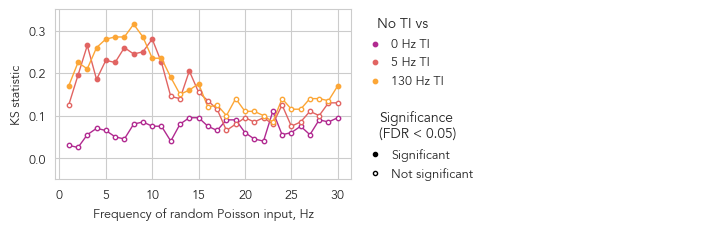

In [13]:
fig = plt.figure(figsize = (8.4, 2.5))
outer_gs = gridspec.GridSpec(1, 2)

inner_gs = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec = outer_gs[0])

# Add and hide plot on the right (otherwise legend does not show up)
ax = fig.add_subplot(outer_gs[0, 1])
for spine_name, spine in ax.spines.items():
    spine.set_visible(spine_name == "left")

ax.get_xaxis().set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.axis("off")

# Add the actual plot on the left
ax = fig.add_subplot(outer_gs[0, 0])

for condition in ["0 Hz TI", "5 Hz TI", "130 Hz TI"]:
    ks_plot = ks_result[(ks_result.Condition1 == "No TI") & (ks_result.Condition2 == condition)]

    sig = ks_plot[ks_plot.Qvalue < 0.05]
    nonsig = ks_plot[ks_plot.Qvalue >= 0.05]

    ax.plot(
        ks_plot.Frequency,
        ks_plot.Statistic,
        color = colors[condition],
        linewidth = 1,
        zorder = 1
    )

    ax.scatter(
        sig.Frequency,
        sig.Statistic,
        color = colors[condition],
        label = condition,
        s = 10
    )

    ax.scatter(
        nonsig.Frequency,
        nonsig.Statistic,
        facecolors = "white",
        edgecolors = colors[condition],
        s = 10,
        alpha = 1,
        zorder = 5
    )

legend_elements = [
    Line2D([0], [0], marker = "o", color = "k", markerfacecolor = "k", markersize = 3, linestyle = "None",
           label = "Significant"),
    Line2D([0], [0], marker = "o", color = "k", markerfacecolor = "none", markersize = 3, linestyle = "None",
           label = "Not significant"),
]

ax.set_xlabel("Frequency of random Poisson input, Hz")
ax.set_ylabel("KS statistic")
ax.set_ylim(-0.05, 0.35)

legend = ax.legend(
    title = "Significance\n(FDR < 0.05)",
    handles = legend_elements,
    loc = "center right",
    ncols = 1,
    frameon = False,
    bbox_to_anchor = (1.45, 0.2),
    handletextpad = 0.25
)

plt.gca().add_artist(legend)

ax.legend(
    title = "No TI vs",
    frameon = False,
    loc = "center right",
    ncols = 1,
    bbox_to_anchor = (1.35, 0.75),
    handletextpad = 0.25
)

plt.subplots_adjust(bottom = 0.2)
plt.savefig("bernstein-random-3.png", bbox_inches = "tight")

## Legend

In [23]:
def read_spike_times(idx, rate, carrier = 1000, offset = 5, strength = 0.9, initial_weight = 0.1):
    global project
    
    if carrier is None:
        filename = f"noTI_{initial_weight}"
    else:
        filename = f"{carrier}_{offset}_{strength}_{initial_weight}"

    spike_times = pd.read_csv(
        f"output/{project}/{idx}/random_poisson/{rate}/{filename}/synapse_stimuli.csv",
        header = None
    )
    spike_times = spike_times.fillna('').values.tolist()
    spike_times = [[x for x in row if x != ""] for row in spike_times]

    return spike_times

In [24]:
idx = 0
rate = 5
initial_weight = 0.1

spike_times = read_spike_times(
    idx = idx,
    rate = rate,
    initial_weight = initial_weight,
    carrier = None
)

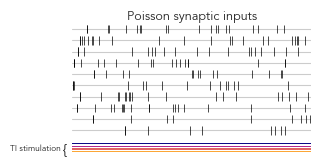

In [27]:
fig = plt.figure(figsize = (8.4, 14))

outer_gs = gridspec.GridSpec(9, 1, height_ratios = [1, 0.2, 2.5, 0.5, 0.7, 0.25, 0.7, 0.25, 0.7])

# --- A and B panels ---

inner_gs_1 = gridspec.GridSpecFromSubplotSpec(5, 4, subplot_spec = outer_gs[0], width_ratios = [0.1, 0.3, 0.01, 0.3], height_ratios = [0.9, 0.01, 0.01, 0.01, 0.01], hspace = 0.05)

### A

ax_a = fig.add_subplot(inner_gs_1[0, 1])

for i, spikes in enumerate(spike_times):
    ax_a.eventplot(spikes, lineoffsets = i + 1, linelengths = 0.75, colors = "black", linewidths = 0.5)

ax_a.set_ylim(0, 11)
ax_a.set_yticks(np.arange(1, 11, 1))
ax_a.set_yticklabels([])

ax_a.set_xlabel("")
ax_a.set_xlim(0, 3000)
ax_a.tick_params(axis = "x", labelbottom = False, which = "both", bottom = False)

ax_a.grid(True)
ax_a.xaxis.grid(False)
ax_a.yaxis.grid(True)

sns.despine(ax = ax_a, top = True, bottom = True, left = True, right = True)

ax_a.set_title("Poisson synaptic inputs", y = 0.925)

################## The NO TI line

ax = fig.add_subplot(inner_gs_1[1, 1])

ax.axvspan(
    0,
    3000,
    color = colors["No TI"],
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(0, 3000)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False, labelbottom = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

################## The 0 Hz TI line

ax = fig.add_subplot(inner_gs_1[2, 1])

ax.axvspan(
    0,
    3000,
    color = colors["0 Hz TI"],
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(0, 3000)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False, labelbottom = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

################## The 5 Hz TI line

ax = fig.add_subplot(inner_gs_1[3, 1])

ax.axvspan(
    0,
    3000,
    color = colors["5 Hz TI"],
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(0, 3000)
ax.set_xticks(np.arange(0, 3200, 500))
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False, labelbottom = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

################## The 130 Hz TI line

ax = fig.add_subplot(inner_gs_1[4, 1])

ax.axvspan(
    0,
    3000,
    color = colors["130 Hz TI"],
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(0, 3000)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(0.21, 0.78665, "TI stimulation", fontsize = 6, va = "center", ha = "center")
fig.text(0.245, 0.78665, "{", fontsize = 10, va = "center", ha = "center")

plt.savefig("bernstein-random-1-protocol.png", dpi = 500, bbox_inches = "tight", transparent = True)